# Action Frequency Analysis for Clash Squad Agent Data

This notebook analyzes the frequency distribution of the first 4 actions across all chunked action data:
- **movementx**: Horizontal movement
- **movementz**: Vertical movement  
- **lookrotationx**: Horizontal look rotation
- **lookrotationz**: Vertical look rotation

Each .npy file contains a 20x10 array representing actions over 20 timesteps.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Define action names
action_names = ['movementx', 'movementz', 'lookrotationx', 'lookrotationz']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

In [23]:
# Path to the actions directory
actions_dir = Path('/Users/vaibhavmishra/Desktop/clash_squad_partitioned_features_chunked/actions')

# Get all .npy files
npy_files = list(actions_dir.glob('*.npy'))
print(f"Found {len(npy_files)} .npy files")

# Sample a few files to understand the data structure
print("\nSample file analysis:")
sample_file = npy_files[0]
sample_data = np.load(sample_file)
print(f"File: {sample_file.name}")
print(f"Shape: {sample_data.shape}")
print(f"First 4 columns (actions):\n{sample_data[:5, :4]}")

Found 66660 .npy files

Sample file analysis:
File: 68389ad6a689278396ffb5db_27515086_actions_chunk_128.npy
Shape: (20, 10)
First 4 columns (actions):
[[ 0.          0.         -0.01188217  0.19678234]
 [ 0.          0.          0.03325945  1.4055414 ]
 [ 0.          0.          0.03290561 10.        ]
 [-0.8802735  -0.46779802 -0.4443065  10.        ]
 [-0.9686182  -0.23969468 -0.7147232  10.        ]]


In [24]:
# Function to collect all action data
def collect_action_data(files, max_files=None):
    """Collect all action data from .npy files"""
    all_actions = []
    
    # Limit files for faster processing
    if max_files:
        files = files[:max_files]
    
    print(f"Processing {len(files)} files...")
    
    for file_path in tqdm(files):
        try:
            data = np.load(file_path)
            # Extract first 4 columns (actions)
            actions = data[:, :4]
            all_actions.append(actions)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    # Concatenate all actions
    if all_actions:
        all_actions = np.vstack(all_actions)
        print(f"Total actions collected: {all_actions.shape}")
        return all_actions
    else:
        return None

# Collect data (limit to first 1000 files for faster processing)
action_data = collect_action_data(npy_files, max_files=1000)

Processing 1000 files...


100%|██████████| 1000/1000 [00:00<00:00, 18924.03it/s]

Total actions collected: (20000, 4)


In [25]:
# Basic statistics for each action
if action_data is not None:
    print("Basic Statistics for Each Action:")
    print("=" * 50)
    
    for i, action_name in enumerate(action_names):
        action_values = action_data[:, i]
        print(f"\n{action_name.upper()}:")
        print(f"  Mean: {action_values.mean():.4f}")
        print(f"  Std:  {action_values.std():.4f}")
        print(f"  Min:  {action_values.min():.4f}")
        print(f"  Max:  {action_values.max():.4f}")
        print(f"  Range: {action_values.max() - action_values.min():.4f}")

Basic Statistics for Each Action:

MOVEMENTX:
  Mean: -0.0245
  Std:  0.4387
  Min:  -1.0000
  Max:  1.0000
  Range: 2.0000

MOVEMENTZ:
  Mean: 0.4761
  Std:  0.5879
  Min:  -1.0000
  Max:  1.0000
  Range: 2.0000

LOOKROTATIONX:
  Mean: 0.0244
  Std:  0.9966
  Min:  -10.0000
  Max:  10.0000
  Range: 20.0000

LOOKROTATIONZ:
  Mean: 0.0803
  Std:  2.5440
  Min:  -10.0000
  Max:  10.0000
  Range: 20.0000


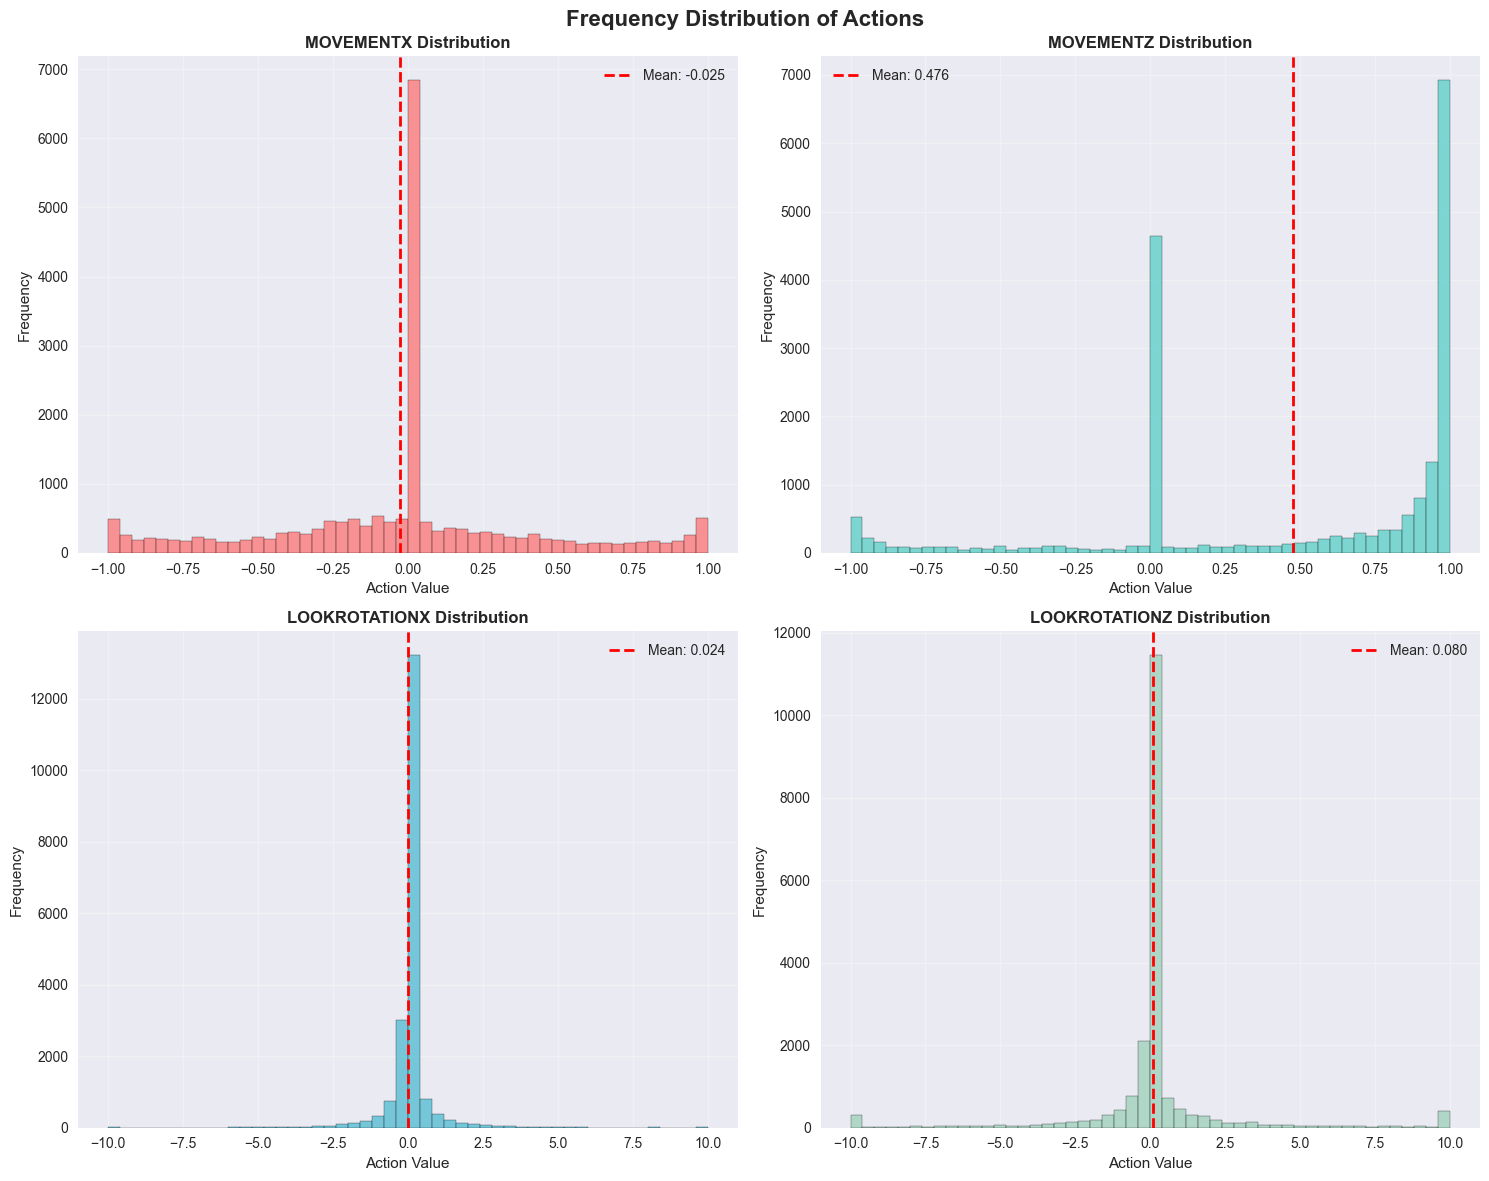

In [26]:
# Create frequency distribution plots
if action_data is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Frequency Distribution of Actions', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for i, (action_name, color) in enumerate(zip(action_names, colors)):
        action_values = action_data[:, i]
        
        # Create histogram
        axes[i].hist(action_values, bins=50, alpha=0.7, color=color, edgecolor='black')
        axes[i].set_title(f'{action_name.upper()} Distribution', fontweight='bold')
        axes[i].set_xlabel('Action Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
        
        # Add statistics text
        mean_val = action_values.mean()
        std_val = action_values.std()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

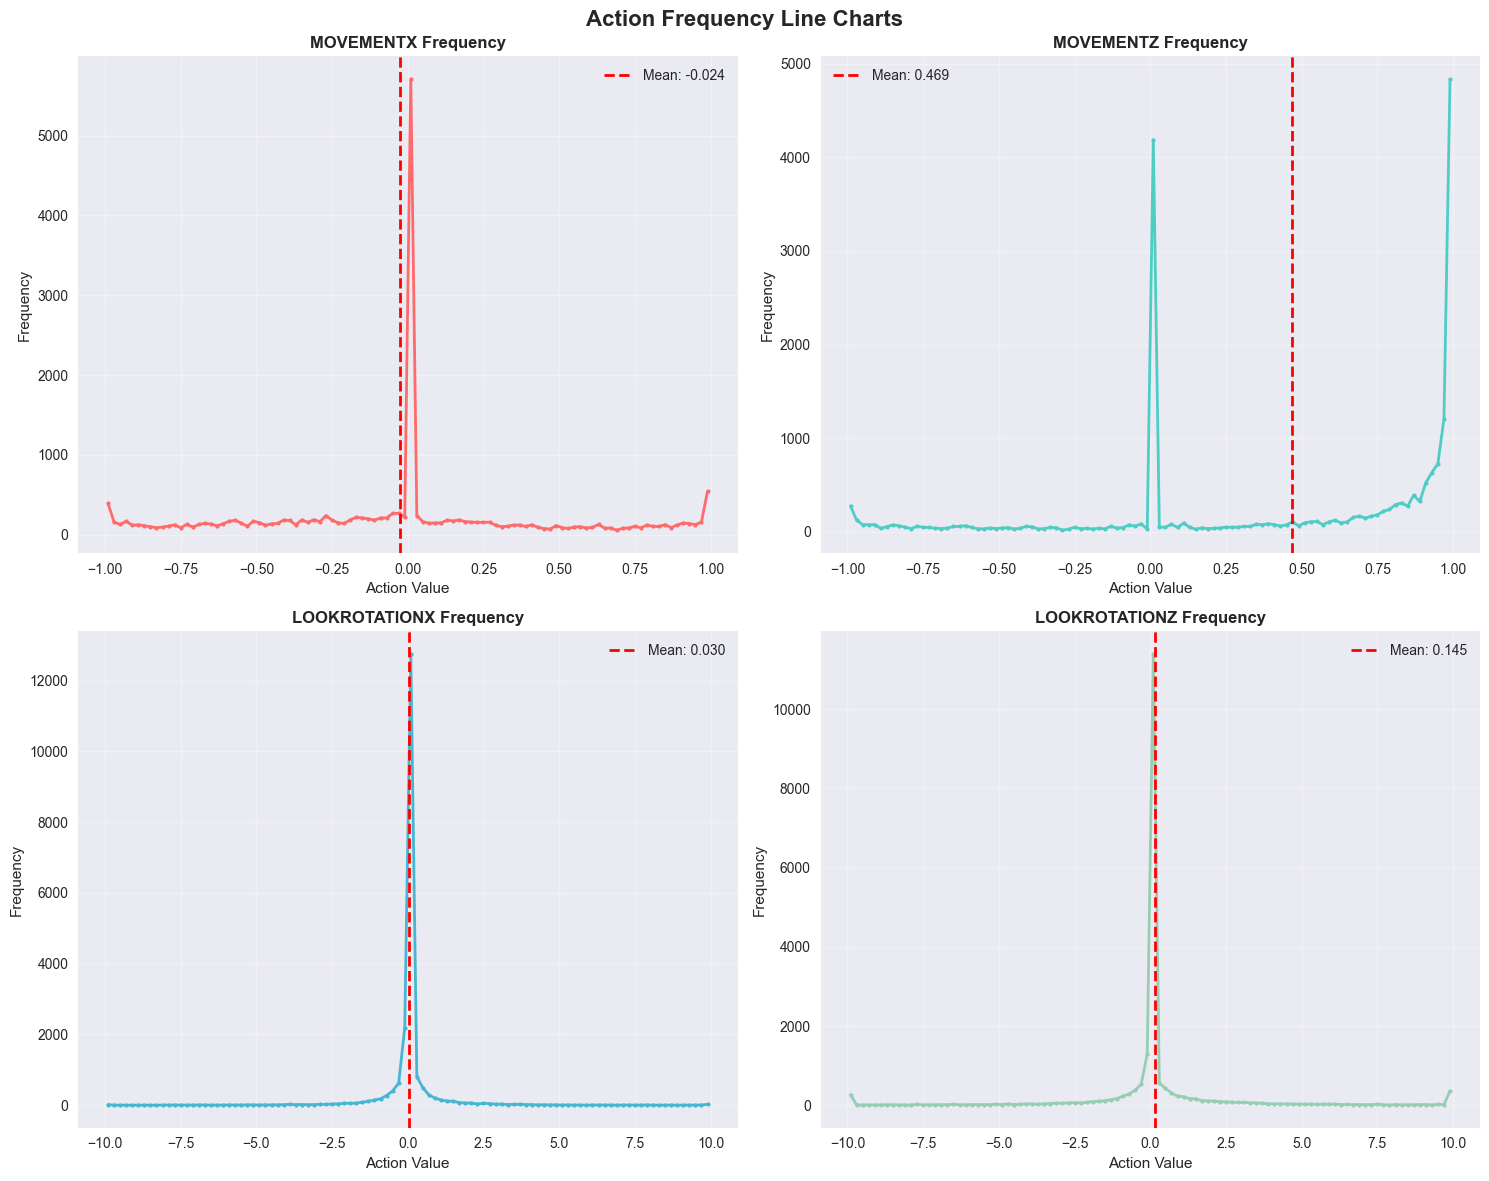

In [6]:
# Create line chart showing frequency over value ranges
if action_data is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Action Frequency Line Charts', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for i, (action_name, color) in enumerate(zip(action_names, colors)):
        action_values = action_data[:, i]
        
        # Create histogram data for line plot
        hist, bin_edges = np.histogram(action_values, bins=100)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Plot line chart
        axes[i].plot(bin_centers, hist, color=color, linewidth=2, marker='o', markersize=3)
        axes[i].set_title(f'{action_name.upper()} Frequency', fontweight='bold')
        axes[i].set_xlabel('Action Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
        
        # Add mean line
        mean_val = action_values.mean()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

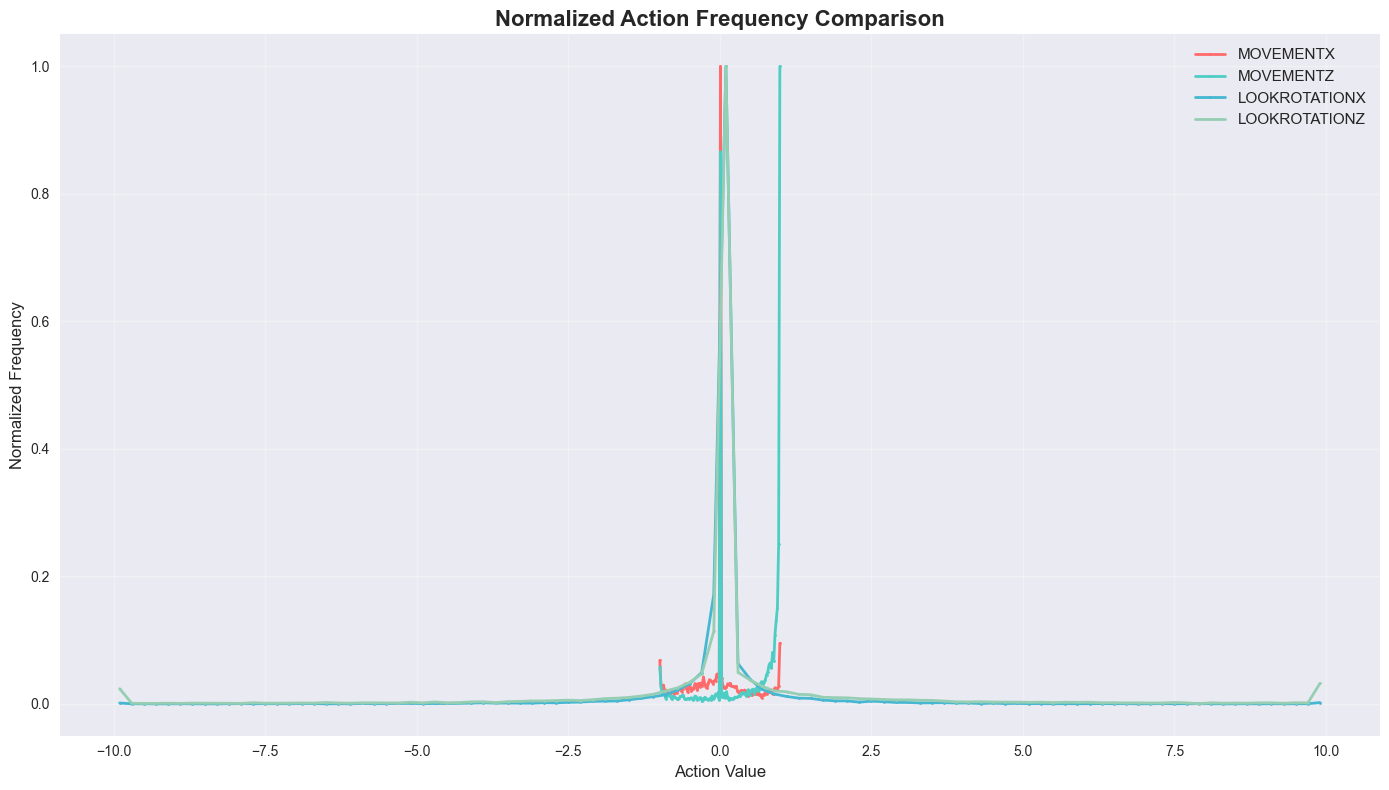

In [7]:
# Combined line chart for all actions
if action_data is not None:
    plt.figure(figsize=(14, 8))
    
    for i, (action_name, color) in enumerate(zip(action_names, colors)):
        action_values = action_data[:, i]
        
        # Create histogram data for line plot
        hist, bin_edges = np.histogram(action_values, bins=100)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Normalize for better comparison
        hist_normalized = hist / hist.max()
        
        plt.plot(bin_centers, hist_normalized, color=color, linewidth=2, 
                label=action_name.upper(), marker='o', markersize=2)
    
    plt.title('Normalized Action Frequency Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Action Value', fontsize=12)
    plt.ylabel('Normalized Frequency', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Value Range Analysis:


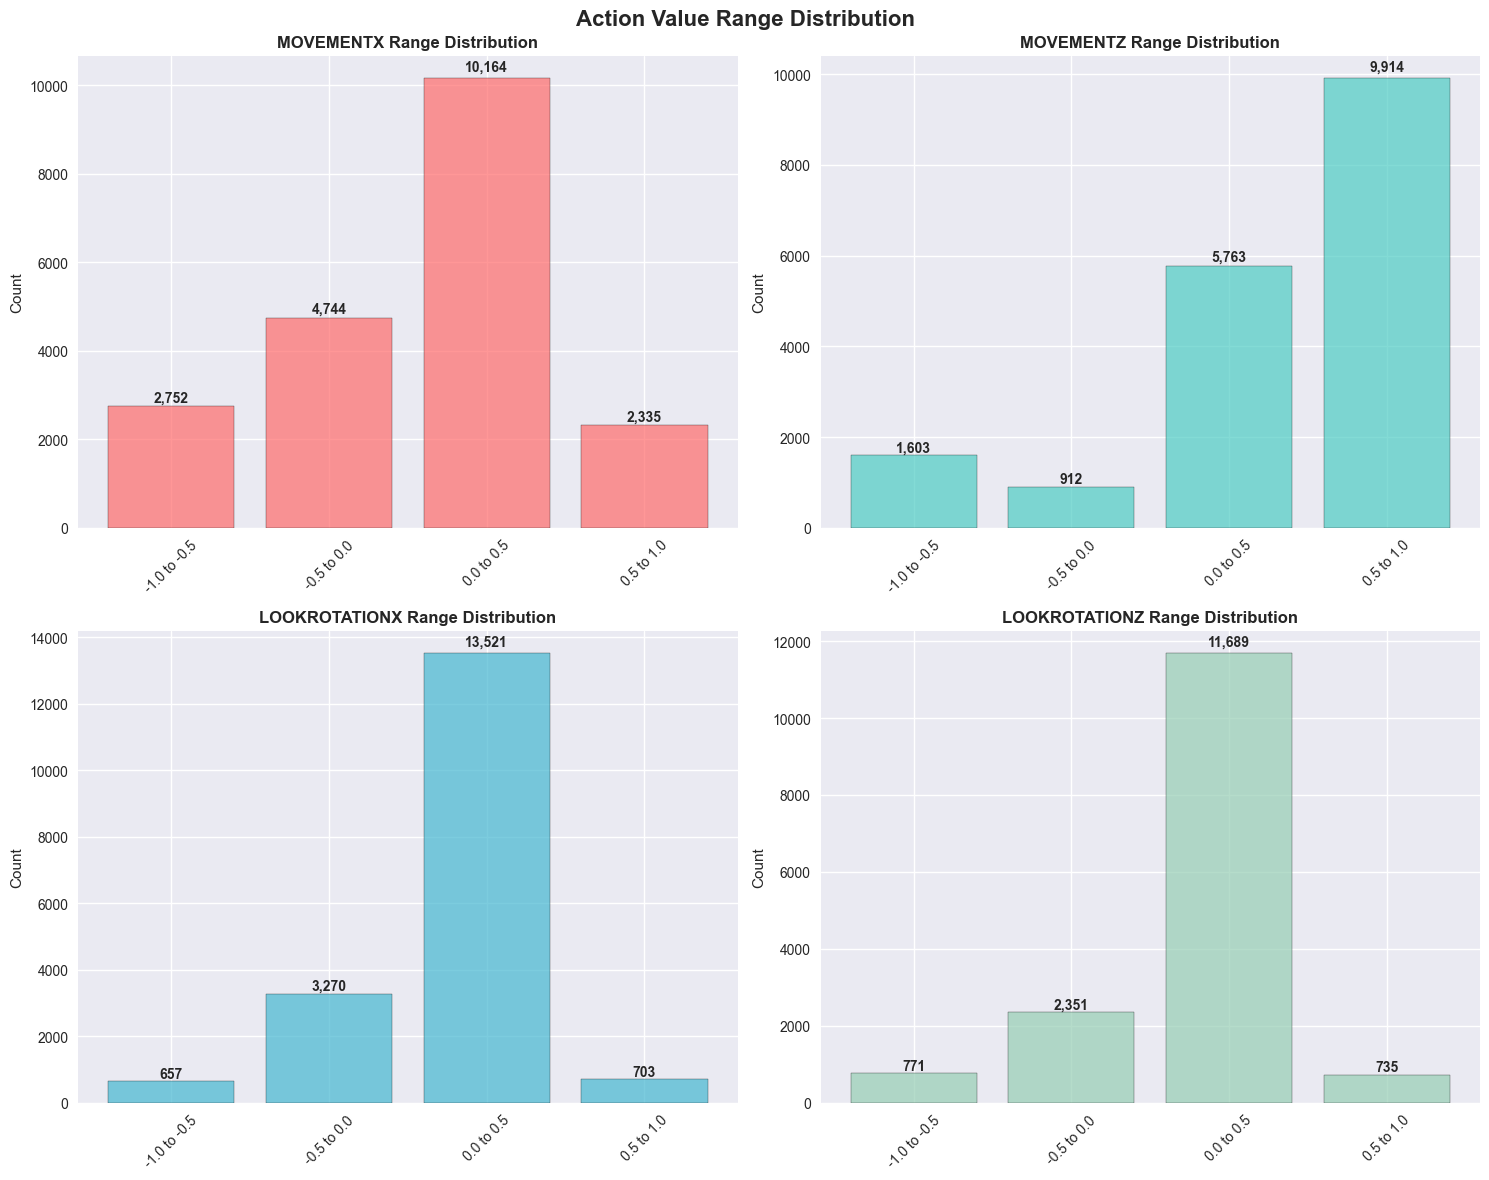


Summary of value ranges:

MOVEMENTX:
  -1.0 to -0.5: 2,752 (13.8%)
  -0.5 to 0.0: 4,744 (23.7%)
  0.0 to 0.5: 10,164 (50.8%)
  0.5 to 1.0: 2,335 (11.7%)

MOVEMENTZ:
  -1.0 to -0.5: 1,603 (8.0%)
  -0.5 to 0.0: 912 (4.6%)
  0.0 to 0.5: 5,763 (28.8%)
  0.5 to 1.0: 9,914 (49.6%)

LOOKROTATIONX:
  -1.0 to -0.5: 657 (3.3%)
  -0.5 to 0.0: 3,270 (16.4%)
  0.0 to 0.5: 13,521 (67.6%)
  0.5 to 1.0: 703 (3.5%)

LOOKROTATIONZ:
  -1.0 to -0.5: 771 (3.9%)
  -0.5 to 0.0: 2,351 (11.8%)
  0.0 to 0.5: 11,689 (58.4%)
  0.5 to 1.0: 735 (3.7%)


In [27]:
# Value range analysis
if action_data is not None:
    print("Value Range Analysis:")
    print("=" * 50)
    
    # Create value range bins
    ranges = [(-1.0, -0.5), (-0.5, 0.0), (0.0, 0.5), (0.5, 1.0)]
    range_labels = ['-1.0 to -0.5', '-0.5 to 0.0', '0.0 to 0.5', '0.5 to 1.0']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Action Value Range Distribution', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for i, (action_name, color) in enumerate(zip(action_names, colors)):
        action_values = action_data[:, i]
        
        # Count values in each range
        range_counts = []
        for low, high in ranges:
            count = np.sum((action_values >= low) & (action_values < high))
            range_counts.append(count)
        
        # Plot bar chart
        bars = axes[i].bar(range_labels, range_counts, color=color, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{action_name.upper()} Range Distribution', fontweight='bold')
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, count in zip(bars, range_counts):
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                        f'{count:,}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nSummary of value ranges:")
    for i, action_name in enumerate(action_names):
        action_values = action_data[:, i]
        print(f"\n{action_name.upper()}:")
        for j, (low, high) in enumerate(ranges):
            count = np.sum((action_values >= low) & (action_values < high))
            percentage = (count / len(action_values)) * 100
            print(f"  {range_labels[j]}: {count:,} ({percentage:.1f}%)")

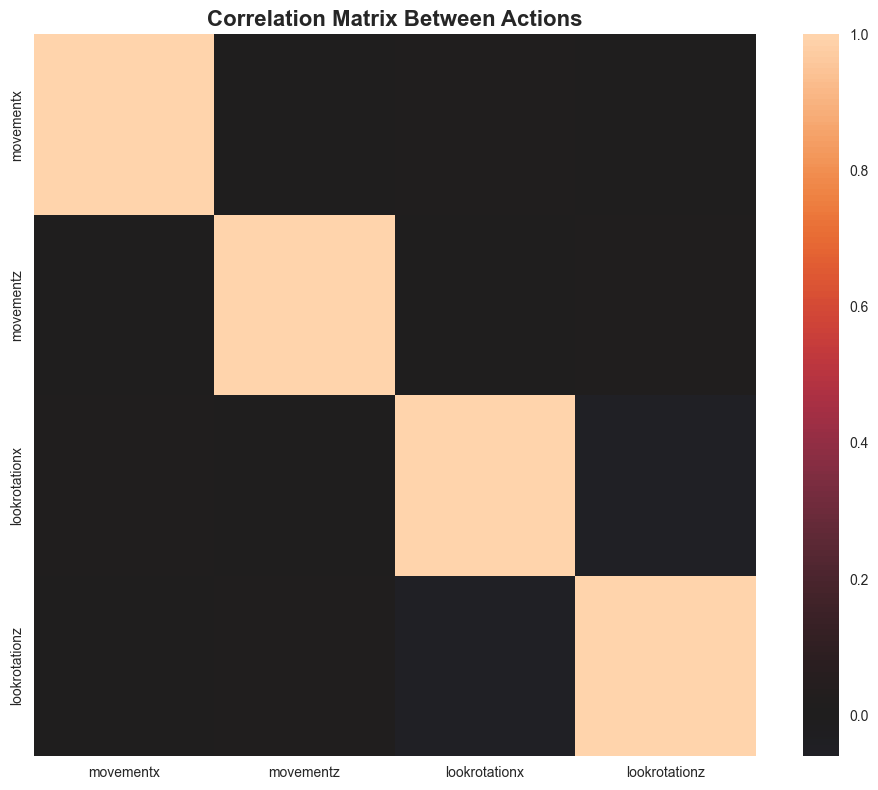


Correlation Analysis:
movementx vs movementz: 0.003
movementx vs lookrotationx: 0.016
movementx vs lookrotationz: 0.004
movementz vs lookrotationx: -0.001
movementz vs lookrotationz: 0.012
lookrotationx vs lookrotationz: -0.060


In [28]:
# Correlation analysis between actions
if action_data is not None:
    # Create correlation matrix
    correlation_matrix = np.corrcoef(action_data.T)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, 
                xticklabels=action_names, 
                yticklabels=action_names, 
                center=0,
                square=True,
                fmt='.3f')
    
    plt.title('Correlation Matrix Between Actions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nCorrelation Analysis:")
    print("=" * 30)
    for i in range(len(action_names)):
        for j in range(i+1, len(action_names)):
            corr = correlation_matrix[i, j]
            print(f"{action_names[i]} vs {action_names[j]}: {corr:.3f}")

In [29]:
# Summary statistics table
if action_data is not None:
    summary_data = []
    
    for i, action_name in enumerate(action_names):
        action_values = action_data[:, i]
        
        summary_data.append({
            'Action': action_name.upper(),
            'Mean': f"{action_values.mean():.4f}",
            'Std': f"{action_values.std():.4f}",
            'Min': f"{action_values.min():.4f}",
            'Max': f"{action_values.max():.4f}",
            'Range': f"{action_values.max() - action_values.min():.4f}",
            'Total_Values': f"{len(action_values):,}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("Summary Statistics:")
    print("=" * 50)
    print(summary_df.to_string(index=False))

Summary Statistics:
       Action    Mean    Std      Min     Max   Range Total_Values
    MOVEMENTX -0.0245 0.4387  -1.0000  1.0000  2.0000       20,000
    MOVEMENTZ  0.4761 0.5879  -1.0000  1.0000  2.0000       20,000
LOOKROTATIONX  0.0244 0.9966 -10.0000 10.0000 20.0000       20,000
LOOKROTATIONZ  0.0803 2.5440 -10.0000 10.0000 20.0000       20,000
